In [5]:
# ============================================================
# BACKTESTING D'IMPUTATION DEMOGRAPHIQUE
# Benchmark : Arithmétique vs Géométrique/TCAM vs Spline
# Données : populations réelles 2004, 2014, 2024
# Objectif : choisir la meilleure méthode pour reconstituer
#            les années inter-censitaires 2005-2013 et 2015-2023
# ============================================================

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d, UnivariateSpline


# ============================================================
# 1. PARAMÈTRES GÉNÉRAUX
# ============================================================

INPUT_FILE = "indicateur_population.csv"

COL_ZONE = "Zone géographique"
COL_2004 = "2004"
COL_2014 = "2014"
COL_2024 = "2024"

EPSILON = 1e-9  # sécurité numérique contre les divisions par zéro


# ============================================================
# 2. FONCTIONS UTILITAIRES
# ============================================================

def clean_population_column(series: pd.Series) -> pd.Series:
    """
    Nettoie une colonne de population :
    - remplace les tirets ou valeurs invalides par NaN
    - convertit en float64
    - garantit une précision numérique stable
    """
    return (
        series
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN"], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(np.float64)
    )


def safe_mape(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """
    Calcule le MAPE de manière robuste.
    Pour éviter les divisions par zéro, on utilise EPSILON.
    """
    denominator = np.maximum(np.abs(y_true), EPSILON)
    return np.abs((y_true - y_pred) / denominator) * 100


def safe_mae(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """
    Calcule l'erreur absolue moyenne en volume.
    """
    return np.abs(y_true - y_pred)


def predict_spline_2024(pop_2004: float, pop_2014: float) -> float:
    """
    Modèle 3 : interpolation/extrapolation non-linéaire.

   
    """

    years = np.array([2004, 2014], dtype=np.float64)
    values = np.array([pop_2004, pop_2014], dtype=np.float64)

    valid_mask = np.isfinite(values)
    years_valid = years[valid_mask]
    values_valid = values[valid_mask]

    n_points = len(values_valid)

    if n_points < 2:
        return np.nan

    # Avec 2 points, degré maximal possible = 1
    k = min(3, n_points - 1)

    try:
        if k == 1:
            model = interp1d(
                years_valid,
                values_valid,
                kind="linear",
                fill_value="extrapolate",
                bounds_error=False
            )
            return np.float64(model(2024))

        else:
            model = UnivariateSpline(
                years_valid,
                values_valid,
                k=k,
                s=0
            )
            return np.float64(model(2024))

    except Exception:
        return np.nan


# ============================================================
# 3. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ============================================================

df = pd.read_csv(INPUT_FILE)

# Vérification des colonnes minimales
required_columns = [COL_ZONE, COL_2004, COL_2014, COL_2024]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le fichier : {missing_columns}")

# Nettoyage et conversion en float64
for col in [COL_2004, COL_2014, COL_2024]:
    df[col] = clean_population_column(df[col])

# On conserve uniquement les lignes exploitables
df = df.dropna(subset=[COL_2004, COL_2014, COL_2024]).copy()

# Sécurité : suppression des populations négatives
df = df[
    (df[COL_2004] >= 0) &
    (df[COL_2014] >= 0) &
    (df[COL_2024] >= 0)
].copy()

# Passage explicite en float64
df[COL_2004] = df[COL_2004].astype(np.float64)
df[COL_2014] = df[COL_2014].astype(np.float64)
df[COL_2024] = df[COL_2024].astype(np.float64)


# ============================================================
# 4. ÉTAPE 1 : DATA MASKING
# ============================================================

# La population réelle de 2024 est isolée comme Ground Truth
df["Pop_2024_Reelle"] = df[COL_2024].astype(np.float64)

# Les modèles n'ont accès qu'à 2004 et 2014
df["Pop_2004"] = df[COL_2004].astype(np.float64)
df["Pop_2014"] = df[COL_2014].astype(np.float64)


# ============================================================
# 5. ÉTAPE 2 : MODÈLE 1 - CROISSANCE ARITHMÉTIQUE
# ============================================================

df["r_arith"] = (df["Pop_2014"] - df["Pop_2004"]) / 10.0

df["Pred_2024_Arith"] = df["Pop_2014"] + (df["r_arith"] * 10.0)


# ============================================================
# 6. ÉTAPE 3 : MODÈLE 2 - CROISSANCE GÉOMÉTRIQUE / TCAM
# ============================================================

# Cas standard : Pop_2004 > 0
valid_geom = df["Pop_2004"] > EPSILON

df["TCAM"] = np.nan

df.loc[valid_geom, "TCAM"] = (
    (df.loc[valid_geom, "Pop_2014"] / df.loc[valid_geom, "Pop_2004"]) ** (1.0 / 10.0)
) - 1.0

df["Pred_2024_Geom"] = np.nan

df.loc[valid_geom, "Pred_2024_Geom"] = (
    df.loc[valid_geom, "Pop_2014"] *
    ((1.0 + df.loc[valid_geom, "TCAM"]) ** 10.0)
)

# Pour les cas où Pop_2004 vaut 0 ou est trop faible,
# on utilise un fallback arithmétique pour éviter une explosion numérique.
df.loc[~valid_geom, "Pred_2024_Geom"] = df.loc[~valid_geom, "Pred_2024_Arith"]


# ============================================================
# 7. ÉTAPE 4 : MODÈLE 3 - SPLINES / EXTRAPOLATION
# ============================================================

df["Pred_2024_Spline"] = df.apply(
    lambda row: predict_spline_2024(
        row["Pop_2004"],
        row["Pop_2014"]
    ),
    axis=1
)

# Fallback si la spline échoue
df["Pred_2024_Spline"] = df["Pred_2024_Spline"].fillna(df["Pred_2024_Arith"])


# ============================================================
# 8. ÉTAPE 5 : ÉVALUATION ET BENCHMARKING
# ============================================================

models = {
    "Arithmétique": "Pred_2024_Arith",
    "Géométrique_TCAM": "Pred_2024_Geom",
    "Spline": "Pred_2024_Spline"
}

for model_name, pred_col in models.items():
    df[f"MAPE_{model_name}"] = safe_mape(
        df["Pop_2024_Reelle"].values,
        df[pred_col].values
    )

    df[f"MAE_{model_name}"] = safe_mae(
        df["Pop_2024_Reelle"].values,
        df[pred_col].values
    )


# ============================================================
# 9. SYNTHÈSE GLOBALE
# ============================================================

summary_rows = []

for model_name in models.keys():
    summary_rows.append({
        "Modèle": model_name,
        "MAPE moyen (%)": df[f"MAPE_{model_name}"].mean(),
        "MAPE médian (%)": df[f"MAPE_{model_name}"].median(),
        "MAE moyenne": df[f"MAE_{model_name}"].mean(),
        "MAE totale": df[f"MAE_{model_name}"].sum()
    })

summary = pd.DataFrame(summary_rows)

summary = summary.sort_values(
    by="MAPE moyen (%)",
    ascending=True
).reset_index(drop=True)

print("\n==============================")
print("BENCHMARK GLOBAL DES MÉTHODES")
print("==============================\n")
print(summary)


# ============================================================
# 10. DÉCISION AUTOMATIQUE
# ============================================================

winning_model = summary.loc[0, "Modèle"]

print("\n==============================")
print("DÉCISION AUTOMATIQUE")
print("==============================\n")

print(
    f"La méthode [{winning_model}] est la plus performante. "
    "C'est elle qui sera retenue pour lisser et reconstituer toute la base de données inter-censitaire."
)


# ============================================================
# 11. EXPORT DES RÉSULTATS DÉTAILLÉS
# ============================================================

output_columns = [
    COL_ZONE,
    "Pop_2004",
    "Pop_2014",
    "Pop_2024_Reelle",
    "Pred_2024_Arith",
    "Pred_2024_Geom",
    "Pred_2024_Spline",
    "MAPE_Arithmétique",
    "MAPE_Géométrique_TCAM",
    "MAPE_Spline",
    "MAE_Arithmétique",
    "MAE_Géométrique_TCAM",
    "MAE_Spline"
]

df_results = df[output_columns].copy()

df_results.to_csv(
    "benchmark_imputation_population_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    "synthese_benchmark_imputation.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nFichiers exportés :")
print("- benchmark_imputation_population_2024.csv")
print("- synthese_benchmark_imputation.csv")


BENCHMARK GLOBAL DES MÉTHODES

             Modèle  MAPE moyen (%)  MAPE médian (%)   MAE moyenne  \
0      Arithmétique       13.273137         9.273400  10429.514124   
1            Spline       13.273137         9.273400  10429.514124   
2  Géométrique_TCAM       14.168907         9.355958  13398.561733   

     MAE totale  
0  1.846024e+06  
1  1.846024e+06  
2  2.371545e+06  

DÉCISION AUTOMATIQUE

La méthode [Arithmétique] est la plus performante. C'est elle qui sera retenue pour lisser et reconstituer toute la base de données inter-censitaire.

Fichiers exportés :
- benchmark_imputation_population_2024.csv
- synthese_benchmark_imputation.csv


In [1]:
# ============================================================
# PIPELINE DE RECONSTITUTION HYBRIDE DES POPULATIONS COMMUNALES
# Projet : Projections démographiques HCP
# Période finale : 2004-2024
#
# Phase 1 : 2005-2013 par interpolation géométrique TCAM
# Phase 2 : 2015-2023 par calibrage progressif des estimations HCP
# Phase 3 : export Wide + Long pour Machine Learning
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. PARAMÈTRES GÉNÉRAUX
# ============================================================

INPUT_FILE = "indicateur_population.csv"

OUTPUT_WIDE = "population_reconstituee_hybride_wide.csv"
OUTPUT_LONG = "population_reconstituee_hybride_long.csv"

COL_ZONE = "Zone géographique"

YEAR_2004 = "2004"
YEAR_2014 = "2014"
YEAR_2024 = "2024"

YEARS_INTERPOLATION = list(range(2005, 2014))  # 2005-2013
YEARS_HCP = list(range(2015, 2024))            # 2015-2023
YEARS_FINAL = list(range(2004, 2025))          # 2004-2024

EPSILON = 1e-9


# ============================================================
# 2. FONCTIONS UTILITAIRES
# ============================================================

def clean_numeric_column(series: pd.Series) -> pd.Series:
    """
    Nettoie une colonne numérique et la convertit en float64.

    Objectif :
    - garder la précision maximale pendant tout le pipeline ;
    - éviter les erreurs liées aux virgules, tirets ou chaînes vides.
    """
    return (
        series
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN", None], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(np.float64)
    )


def safe_tcam(pop_start: pd.Series, pop_end: pd.Series, n_years: int = 10) -> pd.Series:
    """
    Calcule le TCAM de manière sécurisée.

    Formule :
        TCAM = (Pop_end / Pop_start)^(1/n_years) - 1

    Gestion des cas problématiques :
    - si Pop_start <= 0, le TCAM géométrique est impossible ;
    - on retourne NaN, puis on utilisera un fallback linéaire.
    """
    pop_start = pop_start.astype(np.float64)
    pop_end = pop_end.astype(np.float64)

    valid = (pop_start > EPSILON) & (pop_end >= 0)

    tcam = pd.Series(np.nan, index=pop_start.index, dtype=np.float64)

    tcam.loc[valid] = (
        (pop_end.loc[valid] / pop_start.loc[valid]) ** (1.0 / n_years)
    ) - 1.0

    return tcam


# ============================================================
# 3. CHARGEMENT ET CONTRÔLE DES DONNÉES
# ============================================================

df_raw = pd.read_csv(INPUT_FILE)

required_columns = (
    [COL_ZONE, YEAR_2004, YEAR_2014, YEAR_2024]
    + [str(y) for y in YEARS_HCP]
)

missing_columns = [col for col in required_columns if col not in df_raw.columns]

if missing_columns:
    raise ValueError(
        f"Colonnes manquantes dans le fichier source : {missing_columns}"
    )

df = df_raw.copy()

numeric_cols = [str(y) for y in [2004, 2014] + YEARS_HCP + [2024]]

for col in numeric_cols:
    df[col] = clean_numeric_column(df[col])

# ============================================================
# FILTRAGE DES CENTRES SANS HISTORIQUE
# ============================================================

# Objectif :
# Supprimer les centres/communes qui existent uniquement en 2024
# et qui n'ont pas de données historiques suffisantes avant 2024.

initial_count = len(df)

df = df[
    df[YEAR_2004].notna()
    & df[YEAR_2014].notna()
    & df[YEAR_2024].notna()
].copy()

removed_count = initial_count - len(df)

print("\n==============================================")
print("FILTRAGE DES CENTRES SANS HISTORIQUE")
print("==============================================")
print(f"Nombre d'entités initiales  : {initial_count}")
print(f"Nombre d'entités supprimées : {removed_count}")
print(f"Nombre d'entités conservées : {len(df)}")

# Suppression des lignes sans identifiant géographique
df = df.dropna(subset=[COL_ZONE]).copy()

# Passage explicite en float64
for col in numeric_cols:
    df[col] = df[col].astype(np.float64)


# ============================================================
# 4. PHASE 1 : INTERPOLATION GÉOMÉTRIQUE 2005-2013
# ============================================================

df["TCAM_2004_2014"] = safe_tcam(
    pop_start=df[YEAR_2004],
    pop_end=df[YEAR_2014],
    n_years=10
)

# Fallback linéaire si TCAM impossible
# Exemple : Pop_2004 = 0
df["Increment_Lineaire_2004_2014"] = (
    df[YEAR_2014] - df[YEAR_2004]
) / 10.0

for year in YEARS_INTERPOLATION:
    year_str = str(year)
    exponent = year - 2004

    # Cas géométrique valide
    geom_values = (
        df[YEAR_2004]
        * ((1.0 + df["TCAM_2004_2014"]) ** exponent)
    )

    # Fallback linéaire pour populations nulles ou TCAM non calculable
    linear_values = (
        df[YEAR_2004]
        + df["Increment_Lineaire_2004_2014"] * exponent
    )

    df[year_str] = np.where(
        df["TCAM_2004_2014"].notna(),
        geom_values,
        linear_values
    ).astype(np.float64)


# ============================================================
# 5. PHASE 2 : CALIBRAGE RÉTROSPECTIF 2015-2023
# ============================================================

# Erreur finale observée en 2024 :
# Erreur = RGPH réel 2024 - estimation/projection HCP 2024
#
# Attention :
# Dans ce fichier, la colonne 2024 est considérée comme RGPH réel.
# Si tu as une colonne séparée HCP_2024, remplace df[YEAR_2024]
# dans Pop_HCP_2024 par cette colonne.

if "HCP_2024" in df.columns:
    df["Pop_HCP_2024"] = clean_numeric_column(df["HCP_2024"])
else:
    # Cas de ton fichier actuel :
    # comme on n'a pas de colonne HCP_2024 distincte, on suppose que
    # la trajectoire HCP 2015-2023 doit être calibrée vers le RGPH 2024.
    #
    # Pour calculer une erreur HCP 2024, il faut idéalement une vraie
    # estimation HCP 2024. À défaut, on extrapole temporairement HCP_2024
    # à partir de la tendance HCP 2022-2023.
    df["Pop_HCP_2024"] = df["2023"] + (df["2023"] - df["2022"])

df["Erreur_HCP_2024"] = (
    df[YEAR_2024] - df["Pop_HCP_2024"]
).astype(np.float64)

for year in YEARS_HCP:
    year_str = str(year)

    poids = (year - 2014) / 10.0

    df[year_str] = (
        df[year_str]
        + df["Erreur_HCP_2024"] * poids
    ).astype(np.float64)


# Forcer les années d'ancrage réelles
df["2004"] = df[YEAR_2004].astype(np.float64)
df["2014"] = df[YEAR_2014].astype(np.float64)
df["2024"] = df[YEAR_2024].astype(np.float64)


# ============================================================
# 6. PHASE 3 : FORMATAGE FINAL WIDE
# ============================================================

final_year_cols = [str(y) for y in YEARS_FINAL]

df_wide = df[[COL_ZONE] + final_year_cols].copy()

# Conservation float64 jusqu'ici
for col in final_year_cols:
    df_wide[col] = df_wide[col].astype(np.float64)


# ============================================================
# 7. VERSION ARRONDIE FINALE
# ============================================================

df_wide_rounded = df_wide.copy()

for col in final_year_cols:
    df_wide_rounded[col] = df_wide_rounded[col].round(0).astype("Int64")


# ============================================================
# 8. FORMAT LONG / TIDY DATA
# ============================================================

df_long = df_wide_rounded.melt(
    id_vars=[COL_ZONE],
    value_vars=final_year_cols,
    var_name="Année",
    value_name="Population"
)

df_long["Année"] = df_long["Année"].astype(int)
df_long["Population"] = df_long["Population"].astype("Int64")

df_long = df_long.sort_values(
    by=[COL_ZONE, "Année"]
).reset_index(drop=True)


# ============================================================
# 9. EXPORT DES RÉSULTATS
# ============================================================

df_wide_rounded.to_csv(
    OUTPUT_WIDE,
    index=False,
    encoding="utf-8-sig"
)

df_long.to_csv(
    OUTPUT_LONG,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 10. RAPPORT DE CONTRÔLE
# ============================================================

print("\n==============================================")
print("PIPELINE DE RECONSTITUTION HYBRIDE TERMINÉ")
print("==============================================\n")

print(f"Nombre d'entités traitées : {len(df_wide_rounded)}")
print(f"Période reconstruite      : {YEARS_FINAL[0]}-{YEARS_FINAL[-1]}")

print("\nFichiers générés :")
print(f"- {OUTPUT_WIDE}")
print(f"- {OUTPUT_LONG}")

print("\nAperçu format Wide :")
print(df_wide_rounded.head())

print("\nAperçu format Long :")
print(df_long.head(15))

print("\nContrôle des années disponibles :")
print(df_long.groupby("Année")["Population"].count())


FILTRAGE DES CENTRES SANS HISTORIQUE
Nombre d'entités initiales  : 177
Nombre d'entités supprimées : 0
Nombre d'entités conservées : 177

PIPELINE DE RECONSTITUTION HYBRIDE TERMINÉ

Nombre d'entités traitées : 177
Période reconstruite      : 2004-2024

Fichiers générés :
- population_reconstituee_hybride_wide.csv
- population_reconstituee_hybride_long.csv

Aperçu format Wide :
           Zone géographique      2004      2005      2006      2007  \
0                   National  29891708  30265599  30644166  31027469   
1  Tanger-Tétouan-Al Hoceima   3068833   3114447   3160740   3207720   
2          Al Hoceima (Prov)    395644    396043    396443    396843   
3                 Al Hoceima     55357     55491     55626     55761   
4               Bni Bouayach     15497     15754     16016     16282   

       2008      2009      2010      2011      2012  ...      2015      2016  \
0  31415566  31808517  32206384  32609227  33017109  ...  34070248  34377291   
1   3255399   3303787   33

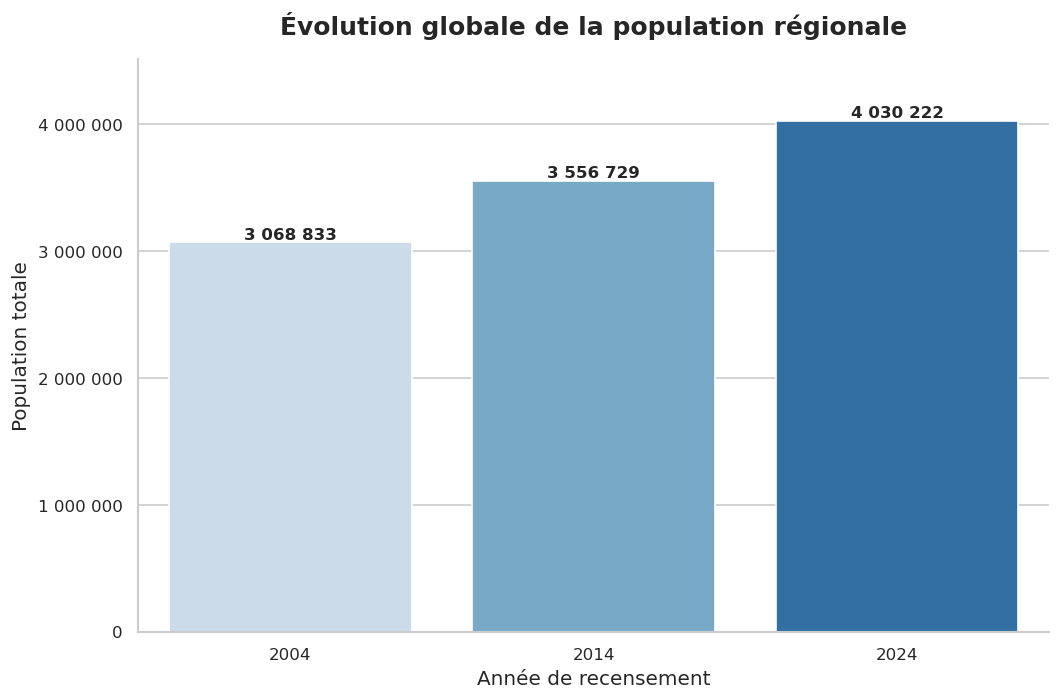

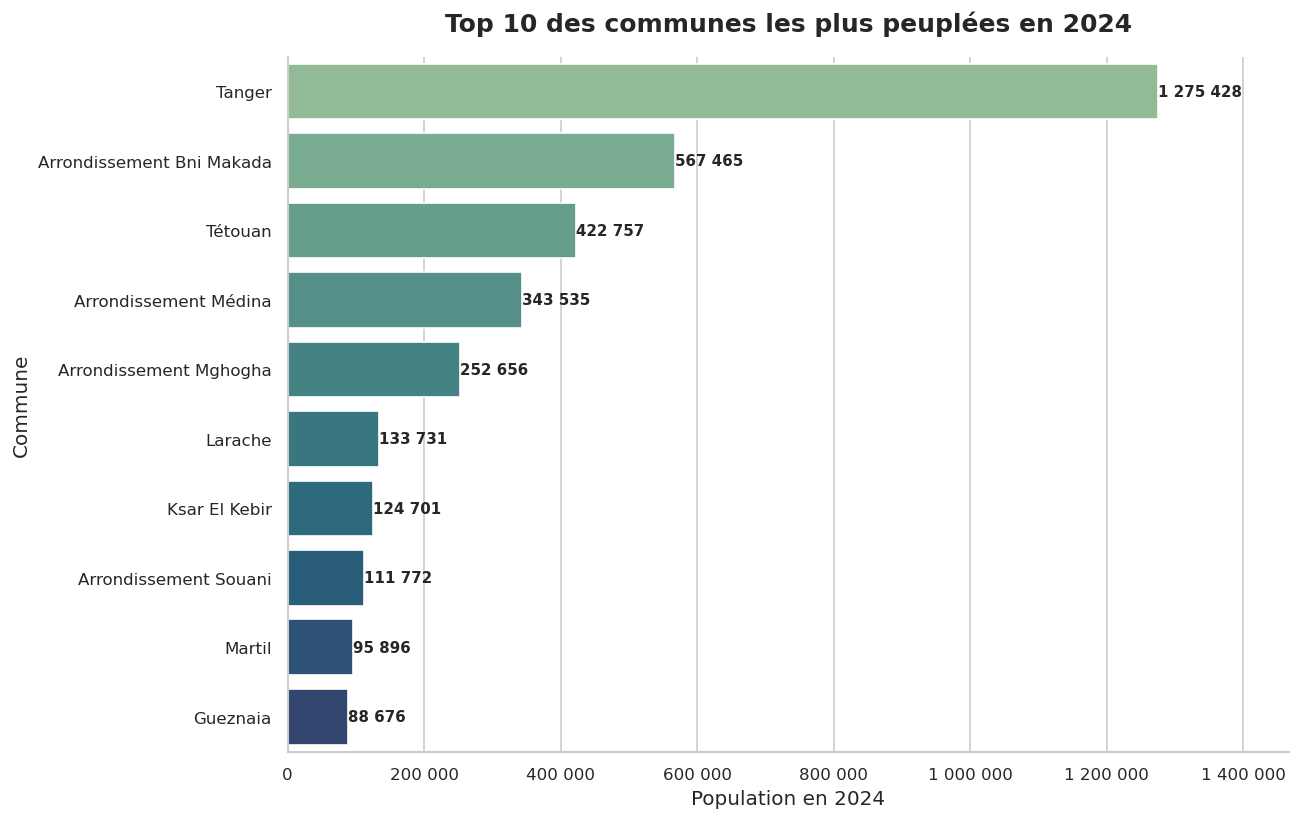

Graphes générés avec succès :
- eda_1_evolution_globale_population_regionale.png
- eda_2_top10_communes_2024.png

Valeurs utilisées pour le graphe régional :
  Année  Population
0  2004   3068833.0
1  2014   3556729.0
2  2024   4030222.0

Top 10 des communes en 2024 :
                       Commune     2024
131                     Tanger  1275428
133  Arrondissement Bni Makada   567465
151                    Tétouan   422757
136      Arrondissement Médina   343535
134     Arrondissement Mghogha   252656
87                     Larache   133731
86               Ksar El Kebir   124701
135      Arrondissement Souani   111772
176                     Martil    95896
137                   Gueznaia    88676


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Chargement des données
# ============================================================

INPUT_FILE = "indicateur_population.csv"
COL_ZONE = "Zone géographique"
YEARS = ["2004", "2014", "2024"]

df = pd.read_csv(INPUT_FILE)

# ============================================================
# 2. Nettoyage
# ============================================================

for col in YEARS:
    df[col] = (
        df[col]
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN"], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[COL_ZONE] = df[COL_ZONE].astype(str).str.strip()

# ============================================================
# 3. Style graphique
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ============================================================
# 4. Graphe 1 : Évolution globale de la population régionale
#    (à partir de la ligne régionale)
# ============================================================

mask_region = df[COL_ZONE].str.lower().str.contains(
    r"tanger[\s\-–—]*t[ée]touan[\s\-–—]*al[\s\-–—]*hoceima",
    regex=True,
    na=False
)

df_region = df.loc[mask_region].copy()

if df_region.empty:
    raise ValueError("La ligne régionale 'Tanger-Tétouan-Al Hoceima' est introuvable dans le fichier.")

region_row = df_region.iloc[0]

evolution_region = pd.DataFrame({
    "Année": YEARS,
    "Population": [region_row["2004"], region_row["2014"], region_row["2024"]]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=evolution_region,
    x="Année",
    y="Population",
    hue="Année",
    palette="Blues",
    legend=False
)
for i, value in enumerate(evolution_region["Population"]):
    ax.text(
        i,
        value,
        f"{value:,.0f}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title("Évolution globale de la population régionale", fontweight="bold", pad=15)
ax.set_xlabel("Année de recensement")
ax.set_ylabel("Population totale")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

ax.set_ylim(0, evolution_region["Population"].max() * 1.12)

sns.despine()
plt.tight_layout()
plt.savefig("eda_1_evolution_globale_population_regionale.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 5. Graphe 2 : Top 10 des communes les plus peuplées en 2024
#    (uniquement selon la disponibilité de 2024)
# ============================================================

pattern_exclusion = (
    r"national|"
    r"tanger[\s\-–—]*t[ée]touan[\s\-–—]*al[\s\-–—]*hoceima|"
    r"prov|"
    r"pr[ée]f"
)

df_top = df[
    ~df[COL_ZONE].str.lower().str.contains(pattern_exclusion, regex=True, na=False)
].copy()

# garder uniquement les lignes ayant une valeur en 2024
df_top = df_top.dropna(subset=["2024"]).copy()

# nettoyage léger des noms
df_top["Commune"] = (
    df_top[COL_ZONE]
    .str.replace(r"\(Commune\)", "", regex=True)
    .str.replace(r"\(Mun\.\)", "", regex=True)
    .str.strip()
)

top10_2024 = (
    df_top.sort_values("2024", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=top10_2024,
    x="2024",
    y="Commune",
    hue="Commune",
    order=top10_2024["Commune"],
    palette="crest",
    legend=False
)

for i, value in enumerate(top10_2024["2024"]):
    ax.text(
        value,
        i,
        f"{value:,.0f}".replace(",", " "),
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("Top 10 des communes les plus peuplées en 2024", fontweight="bold", pad=15)
ax.set_xlabel("Population en 2024")
ax.set_ylabel("Commune")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

ax.set_xlim(0, top10_2024["2024"].max() * 1.15)

sns.despine()
plt.tight_layout()
plt.savefig("eda_2_top10_communes_2024.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 6. Exports de contrôle
# ============================================================

evolution_region.to_csv(
    "controle_evolution_regionale.csv",
    index=False,
    encoding="utf-8-sig"
)

top10_2024[["Commune", "2024"]].to_csv(
    "controle_top10_communes_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Graphes générés avec succès :")
print("- eda_1_evolution_globale_population_regionale.png")
print("- eda_2_top10_communes_2024.png")

print("\nValeurs utilisées pour le graphe régional :")
print(evolution_region)

print("\nTop 10 des communes en 2024 :")
print(top10_2024[["Commune", "2024"]])

In [4]:
"""
merge_hcp2024.py
────────────────
Lit indicateur_population.csv et 2024.csv.
Ajoute une colonne HCP_2024_estime à indicateur_population.csv
en fusionnant sur Zone géographique après normalisation stricte
(minuscules, strip, suppression des accents, espaces multiples réduits).
Aucun fuzzy-matching : correspondance exacte normalisée uniquement.
Sortie : indicateur_population_avec_hcp2024.csv
"""

import unicodedata
import re
import pandas as pd


# ── Helpers ────────────────────────────────────────────────────────────────

def normalize(text: str) -> str:
    """Minuscules · strip · retrait des accents · espaces multiples → un seul."""
    if not isinstance(text, str):
        return ""
    # Minuscules + strip
    text = text.strip().lower()
    # Retrait des accents (décomposition NFD puis suppression des marques)
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    # Espaces multiples → un seul espace
    text = re.sub(r"\s+", " ", text)
    return text


# ── Chargement ─────────────────────────────────────────────────────────────

df_indic = pd.read_csv("indicateur_population.csv")
df_2024  = pd.read_csv("population estimé 2024.csv")

print(f"[INFO] indicateur_population.csv : {len(df_indic)} lignes")
print(f"[INFO] population estimé 2024.csv : {len(df_2024)} lignes")


# ── Normalisation des clés ─────────────────────────────────────────────────

KEY_COL   = "Zone géographique"
POP_COL   = "Population"
NORM_KEY  = "_norm_key"

df_indic[NORM_KEY] = df_indic[KEY_COL].apply(normalize)
df_2024[NORM_KEY]  = df_2024[KEY_COL].apply(normalize)


# ── Construction du mapping normalisé → Population (2024.csv) ──────────────
# En cas de doublons dans 2024.csv après normalisation, on garde le premier.

mapping = (
    df_2024
    .drop_duplicates(subset=NORM_KEY, keep="first")
    .set_index(NORM_KEY)[POP_COL]
)


# ── Fusion stricte (map sur la clé normalisée) ─────────────────────────────

df_indic["HCP_2024_estime"] = df_indic[NORM_KEY].map(mapping)

# Nettoyage : retrait de la colonne de travail
df_indic.drop(columns=[NORM_KEY], inplace=True)


# ── Rapport de correspondance ──────────────────────────────────────────────

total   = len(df_indic)
matched = df_indic["HCP_2024_estime"].notna().sum()
unmatched = total - matched

print(f"\n[RÉSULTAT] Correspondances trouvées : {matched} / {total}")
print(f"[RÉSULTAT] Sans correspondance      : {unmatched} / {total}")

if unmatched > 0:
    print("\n[DÉTAIL] Zones sans correspondance dans indicateur_population.csv :")
    no_match = df_indic.loc[df_indic["HCP_2024_estime"].isna(), KEY_COL]
    for name in no_match:
        print(f"  • {name}")


# ── Export ─────────────────────────────────────────────────────────────────

OUTPUT = "indicateur_population_avec_hcp2024.csv"
df_indic.to_csv(OUTPUT, index=False, encoding="utf-8-sig")
print(f"\n[OK] Fichier écrit : {OUTPUT}")
print(f"     Colonnes : {df_indic.columns.tolist()}")

[INFO] indicateur_population.csv : 177 lignes
[INFO] population estimé 2024.csv : 176 lignes

[RÉSULTAT] Correspondances trouvées : 137 / 177
[RÉSULTAT] Sans correspondance      : 40 / 177

[DÉTAIL] Zones sans correspondance dans indicateur_population.csv :
  • Tanger-Tétouan-Al Hoceima
  • Al Hoceima (Prov)
  • Ajdir (Mun.)
  • Centre: Sidi Bouafif
  • Bni Hadifa
  • Bni Hadifa(Centre)
  • Tamassint
  • Centre: Issaguen
  • Chefchaouen (Prov)
  • Bab Berred(Centre)
  • Bab Taza(Centre)
  • Centre: Jebha
  • Fahs-Anjra (Prov)
  • Larache (Prov)
  • Ksar El Kebir
  • Laouamra
  • Centre: Laouamra
  • Khemis Sahel
  • Ouezzane (Prov)
  • Lamjaara
  • Ain Dorij
  • Brikcha(Centre)
  • Moqrisset
  • Moqrisset(Centre)
  • Centre: Zoumi
  • Tanger-Assilah (Préf)
  • Tanger (Commune)
  • Arrondissement Bni Makada
  • Arrondissement Mghogha
  • Arrondissement Souani
  • Arrondissement Médina
  • Dar Chaoui(Centre)
  • Tnine Sidi Lyamani
  • Tétouan (Prov)
  • Ain Lahsan
  • Jbel Lahbib
  • Kar

In [2]:
import numpy as np
import pandas as pd

# ============================================================
# 1. Paramètres
# ============================================================

INPUT_FILE = "indicateur_population_avec_hcp2024.csv"
OUTPUT_FILE = "dataset_finale.csv"

COL_ZONE = "Zone géographique"
COL_HCP_2024 = "HCP_2024_estime"

YEARS_PHASE1 = range(2005, 2014)   # 2005-2013
YEARS_PHASE2 = range(2015, 2024)   # 2015-2023
YEARS_FINAL = [str(y) for y in range(2004, 2025)]

EPSILON = 1e-9


# ============================================================
# 2. Lecture du fichier
# ============================================================
df = pd.read_csv(
    INPUT_FILE,
    sep=",",
    encoding="utf-8-sig",
    dtype=str
)

df.columns = df.columns.astype(str).str.strip()

# Si le fichier contient une fausse ligne d'en-tête Column1, Column2...
if df.columns[0].lower().startswith("column"):
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()

df.columns = df.columns.astype(str).str.strip()

print("Colonnes détectées :")
print(df.columns.tolist())

df.columns = df.columns.astype(str).str.strip()

# Si le fichier contient Column1, Column2... comme en-tête artificiel,
# on utilise la première ligne comme vrais noms de colonnes.
if df.columns[0].lower().startswith("column"):
    df.columns = df.iloc[0].astype(str).str.strip()
    df = df.iloc[1:].reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()

print("Colonnes détectées :")
print(df.columns.tolist())
# ============================================================
# 3. Correction automatique si les colonnes sont Column1, Column2...
# ============================================================

if "Column1" in df.columns or "\ufeffColumn1" in df.columns:
    new_header = df.iloc[0].astype(str).str.strip().tolist()
    df = df.iloc[1:].copy()
    df.columns = new_header
    df = df.reset_index(drop=True)

df.columns = df.columns.astype(str).str.strip()


# ============================================================
# 4. Vérification des colonnes nécessaires
# ============================================================

required_cols = (
    [COL_ZONE, "2004", "2014", "2024", COL_HCP_2024]
    + [str(y) for y in YEARS_PHASE2]
)

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans le fichier : {missing_cols}")


# ============================================================
# 5. Nettoyage numérique
# ============================================================

numeric_cols = (
    ["2004", "2014", "2024", COL_HCP_2024]
    + [str(y) for y in YEARS_PHASE2]
)

for col in numeric_cols:
    df[col] = (
        df[col]
        .replace(["-", "", " ", "NA", "N/A", "nan", "NaN", None], np.nan)
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

df[COL_ZONE] = df[COL_ZONE].astype(str).str.strip()


# ============================================================
# 6. Phase 1 : Reconstitution 2005-2013 par TCAM
# ============================================================

valid_tcam = (
    (df["2004"] > EPSILON)
    & df["2014"].notna()
    & (df["2014"] >= 0)
)

df["TCAM_2004_2014"] = np.nan

df.loc[valid_tcam, "TCAM_2004_2014"] = (
    (df.loc[valid_tcam, "2014"] / df.loc[valid_tcam, "2004"]) ** (1 / 10)
) - 1

df["Increment_Lineaire_2004_2014"] = (
    df["2014"] - df["2004"]
) / 10

for year in YEARS_PHASE1:
    year_col = str(year)
    exponent = year - 2004

    valeur_geom = (
        df["2004"] *
        ((1 + df["TCAM_2004_2014"]) ** exponent)
    )

    valeur_lineaire = (
        df["2004"] +
        df["Increment_Lineaire_2004_2014"] * exponent
    )

    df[year_col] = np.where(
        df["TCAM_2004_2014"].notna(),
        valeur_geom,
        valeur_lineaire
    ).astype("float64")


# ============================================================
# 7. Phase 2 : Calibrage rétrospectif 2015-2023
# ============================================================

df["Erreur_2024"] = (
    df["2024"] - df[COL_HCP_2024]
).astype("float64")

for year in YEARS_PHASE2:
    year_col = str(year)
    poids = (year - 2014) / 10

    df[year_col] = (
        df[year_col] +
        df["Erreur_2024"] * poids
    ).astype("float64")


# ============================================================
# 8. Contrôle interne
# ============================================================

controle_2024 = df[COL_HCP_2024] + df["Erreur_2024"]
ecart_max = (controle_2024 - df["2024"]).abs().max()

print("Écart maximal après calibrage 2024 :", ecart_max)

if ecart_max > 1e-6:
    raise ValueError("Erreur : le calibrage ne retombe pas exactement sur RGPH 2024.")


# ============================================================
# 9. Dataset final prêt pour entraînement
# ============================================================

dataset_finale = df[[COL_ZONE] + YEARS_FINAL].copy()
dataset_finale = dataset_finale[
    ~dataset_finale[COL_ZONE].astype(str).str.lower().str.contains(
        r"column1|zone géographique|zone geographique",
        na=False,
        regex=True
    )
].copy()

dataset_finale = dataset_finale.reset_index(drop=True)

for col in YEARS_FINAL:
    dataset_finale[col] = dataset_finale[col].round(0).astype("Int64")


# ============================================================
# 10. Export CSV compatible Excel francophone
# ============================================================

dataset_finale.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",
    sep=";"
)

print("Pipeline terminé avec succès.")
print(f"Fichier généré : {OUTPUT_FILE}")
print("Nombre total de lignes conservées :", len(dataset_finale))
print("Colonnes finales :", list(dataset_finale.columns))

Colonnes détectées :
['Zone géographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'HCP_2024_estime']
Colonnes détectées :
['Zone géographique', '2004', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'HCP_2024_estime']
Écart maximal après calibrage 2024 : 0.0
Pipeline terminé avec succès.
Fichier généré : dataset_finale.csv
Nombre total de lignes conservées : 177
Colonnes finales : ['Zone géographique', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


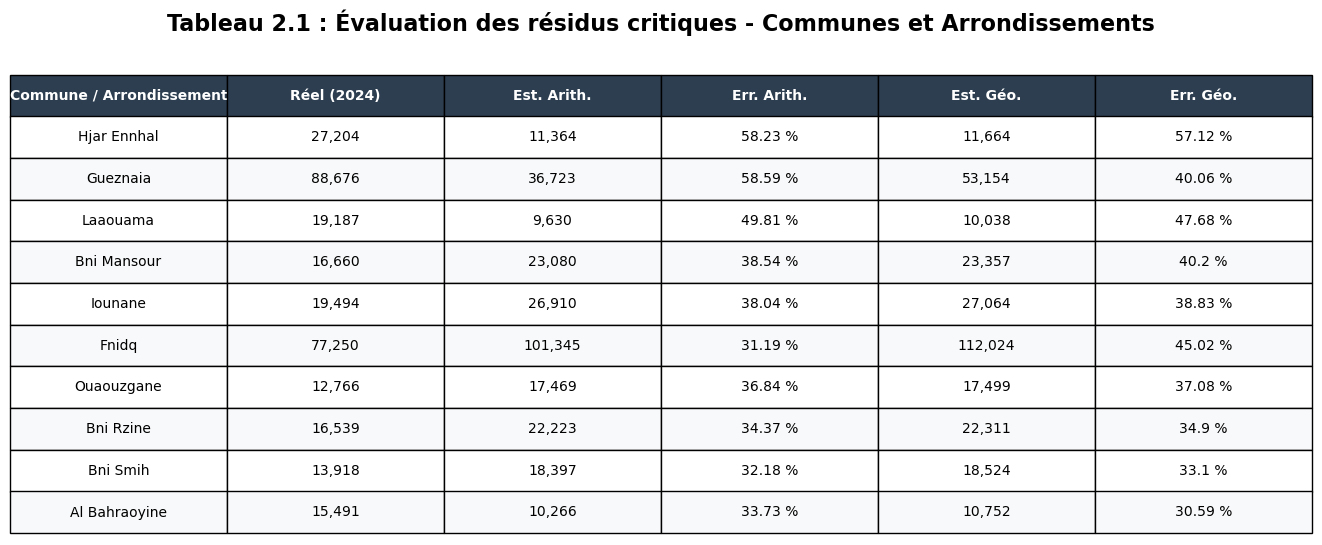

[SUCCÈS] : Fichier 'communes_erreurs_critiques_2024.csv' généré.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Lecture du dataset
df = pd.read_csv('benchmark_imputation_population_2024.csv')

# 2. Calcul des indicateurs de performance (Erreurs relatives)
df['Err. Arith. (%)'] = (df['MAE_Arithmétique'] / df['Pop_2024_Reelle']) * 100
df['Err. Géo. (%)'] = (df['MAE_Géométrique_TCAM'] / df['Pop_2024_Reelle']) * 100

# 3. Filtrage strict : Exclusion des agrégats, Provinces/Préfectures et Centres
# On retire tout ce qui contient (Prov), (Préf), (Centre) ou "Centre:"
filtre_exclure = r'\(Prov\)|\(Préf\)|\(Centre\)|Centre:|National|Tanger-Tétouan-Al Hoceima'
df_communes_pure = df[~df['Zone géographique'].str.contains(filtre_exclure, case=False, na=False)].copy()

# 4. Tri par l'erreur moyenne pour identifier les communes les plus instables
df_communes_pure['Erreur_Moyenne'] = (df_communes_pure['Err. Arith. (%)'] + df_communes_pure['Err. Géo. (%)']) / 2
df_communes_sorted = df_communes_pure.sort_values(by='Erreur_Moyenne', ascending=False)

# 5. Préparation du Top 10 pour le rapport
cols = ['Zone géographique', 'Pop_2024_Reelle', 'Pred_2024_Arith', 'Err. Arith. (%)', 'Pred_2024_Geom', 'Err. Géo. (%)']
top_10_df = df_communes_sorted[cols].head(10).copy()

# Formatage des colonnes pour le rendu visuel
top_10_df['Pop_2024_Reelle'] = top_10_df['Pop_2024_Reelle'].apply(lambda x: f"{int(x):,}")
top_10_df['Pred_2024_Arith'] = top_10_df['Pred_2024_Arith'].apply(lambda x: f"{int(x):,}")
top_10_df['Pred_2024_Geom'] = top_10_df['Pred_2024_Geom'].apply(lambda x: f"{int(x):,}")
top_10_df['Err. Arith. (%)'] = top_10_df['Err. Arith. (%)'].round(2).astype(str) + " %"
top_10_df['Err. Géo. (%)'] = top_10_df['Err. Géo. (%)'].round(2).astype(str) + " %"

# 6. Création du tableau visuel (Style HCP)
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

header_color = '#2c3e50'
row_colors = ['#f8f9fa', 'white']

table = ax.table(
    cellText=top_10_df.values,
    colLabels=['Commune / Arrondissement', 'Réel (2024)', 'Est. Arith.', 'Err. Arith.', 'Est. Géo.', 'Err. Géo.'],
    cellLoc='center',
    loc='center'
)

# Style technique
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor(header_color)
    else:
        cell.set_facecolor(row_colors[row % 2])

plt.title("Tableau 2.1 : Évaluation des résidus critiques - Communes et Arrondissements", fontsize=16, pad=30, weight='bold')
plt.savefig('tableau_communes_final.png', bbox_inches='tight', dpi=300)
plt.show()

# Exportation du CSV filtré
top_10_df.to_csv('communes_erreurs_critiques_2024.csv', index=False, encoding='utf-8-sig')
print("[SUCCÈS] : Fichier 'communes_erreurs_critiques_2024.csv' généré.")

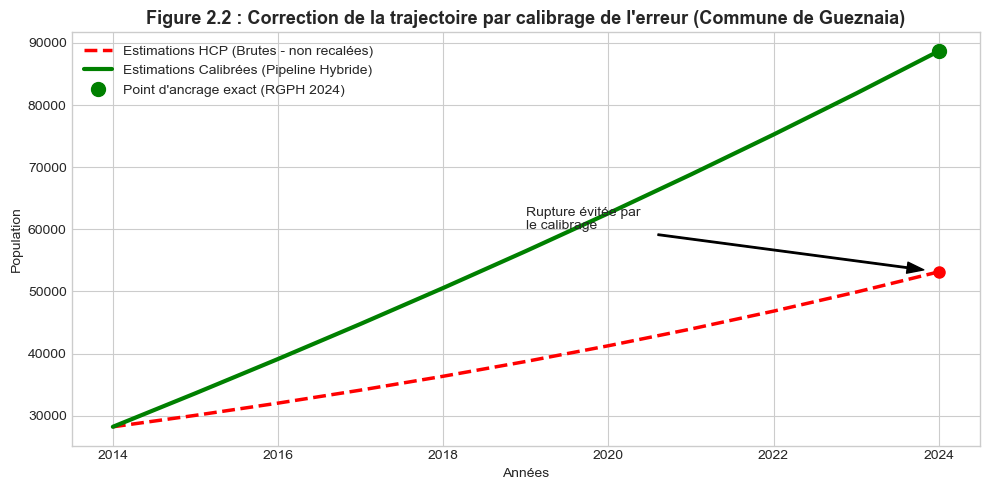

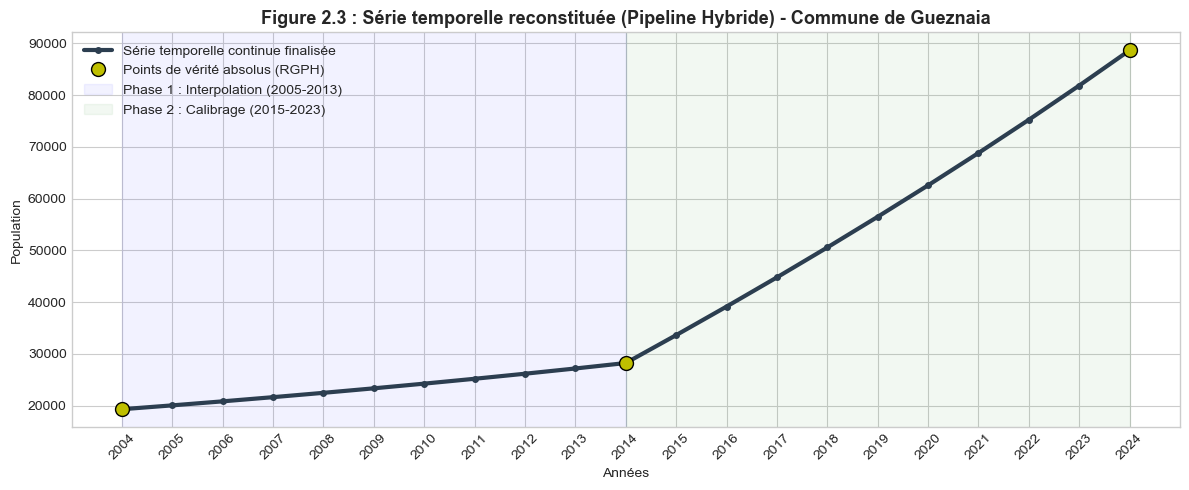

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- SIMULATION DU PIPELINE POUR LA COMMUNE DE GUEZNAIA ---
# Remplacez ces valeurs par les vraies données de Gueznaia issues de votre fichier
annees = np.arange(2004, 2025)

# 1. Données réelles (RGPH)
p2004 = 19284  # Exemple Gueznaia 2004
p2014 = 28217  # Exemple Gueznaia 2014
p2024_reel = 88676 # RGPH 2024

# 2. Phase 1 : Interpolation Géométrique (2004-2014)
tcam_04_14 = (p2014 / p2004)**(1/10) - 1
pop_2004_2014 = [p2004 * (1 + tcam_04_14)**(t - 2004) for t in range(2004, 2015)]

# 3. Estimations HCP Brutes (Simulées pour la démonstration - remplacez par vos data)
# On suppose que le HCP continuait sur une trajectoire plus lente (vers ~53k)
tcam_hcp = (53154 / p2014)**(1/10) - 1
hcp_brute_2015_2024 = [p2014 * (1 + tcam_hcp)**(t - 2014) for t in range(2015, 2025)]

# 4. Phase 2 : Calibrage (Distribution de l'erreur)
erreur_2024 = p2024_reel - hcp_brute_2015_2024[-1]
# Redistribution proportionnelle de l'erreur de 2015 (poids=1/10) à 2024 (poids=10/10)
hcp_calibree_2015_2024 = [hcp_brute_2015_2024[i] + erreur_2024 * ((i+1)/10) for i in range(10)]

# --- CREATION DE LA FIGURE 2.2 (Utilité du Calibrage) ---
plt.figure(figsize=(10, 5))
plt.style.use('seaborn-v0_8-whitegrid')
annees_decennie_2 = np.arange(2014, 2025)
plt.plot(annees_decennie_2, [p2014] + hcp_brute_2015_2024, 'r--', linewidth=2.5, label="Estimations HCP (Brutes - non recalées)")
plt.plot(annees_decennie_2, [p2014] + hcp_calibree_2015_2024, 'g-', linewidth=3, label="Estimations Calibrées (Pipeline Hybride)")
plt.plot(2024, p2024_reel, 'go', markersize=10, label="Point d'ancrage exact (RGPH 2024)")
plt.plot(2024, hcp_brute_2015_2024[-1], 'ro', markersize=8)

plt.annotate('Rupture évitée par\nle calibrage', xy=(2024, hcp_brute_2015_2024[-1]), xytext=(2019, 60000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=10)

# AJOUT DU NOM DE LA COMMUNE DANS LE TITRE
plt.title("Figure 2.2 : Correction de la trajectoire par calibrage de l'erreur (Commune de Gueznaia)", fontsize=13, weight='bold')
plt.xlabel("Années")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.savefig('graphe_calibrage_gueznaia.png', dpi=300) # Changement du nom de fichier
plt.show()

# --- CREATION DE LA FIGURE 2.3 (Série finale 2004-2024) ---
plt.figure(figsize=(12, 5))
serie_finale = pop_2004_2014[:-1] + [p2014] + hcp_calibree_2015_2024[:-1] + [p2024_reel]
plt.plot(annees, serie_finale, color='#2c3e50', linewidth=3, marker='o', markersize=4, label="Série temporelle continue finalisée")
plt.plot([2004, 2014, 2024], [p2004, p2014, p2024_reel], 'yo', markersize=10, label="Points de vérité absolus (RGPH)", markeredgecolor='black')

plt.axvspan(2004, 2014, color='blue', alpha=0.05, label="Phase 1 : Interpolation (2005-2013)")
plt.axvspan(2014, 2024, color='green', alpha=0.05, label="Phase 2 : Calibrage (2015-2023)")

# AJOUT DU NOM DE LA COMMUNE DANS LE TITRE
plt.title("Figure 2.3 : Série temporelle reconstituée (Pipeline Hybride) - Commune de Gueznaia", fontsize=13, weight='bold')
plt.xlabel("Années")
plt.ylabel("Population")
plt.xticks(annees, rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('graphe_serie_finale_gueznaia.png', dpi=300) # Changement du nom de fichier
plt.show()